In [2]:
import os
os.makedirs('outputs', exist_ok=True)
print("Folder created!")

Folder created!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [9]:
df = pd.read_csv('file.csv')
print("Columns:", len(df.columns))
print("Shape:", df.shape)
df.head()

Columns: 21
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print(df.columns.tolist())
print("\nShape:", df.shape)
df.head()


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

df.dropna(subset=['TotalCharges'], inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nChurn rate: {df['Churn'].mean():.1%}")
print(f"Total customers: {len(df)}")

Missing values:
 TotalCharges    11
dtype: int64

Churn rate: 26.6%
Total customers: 7032


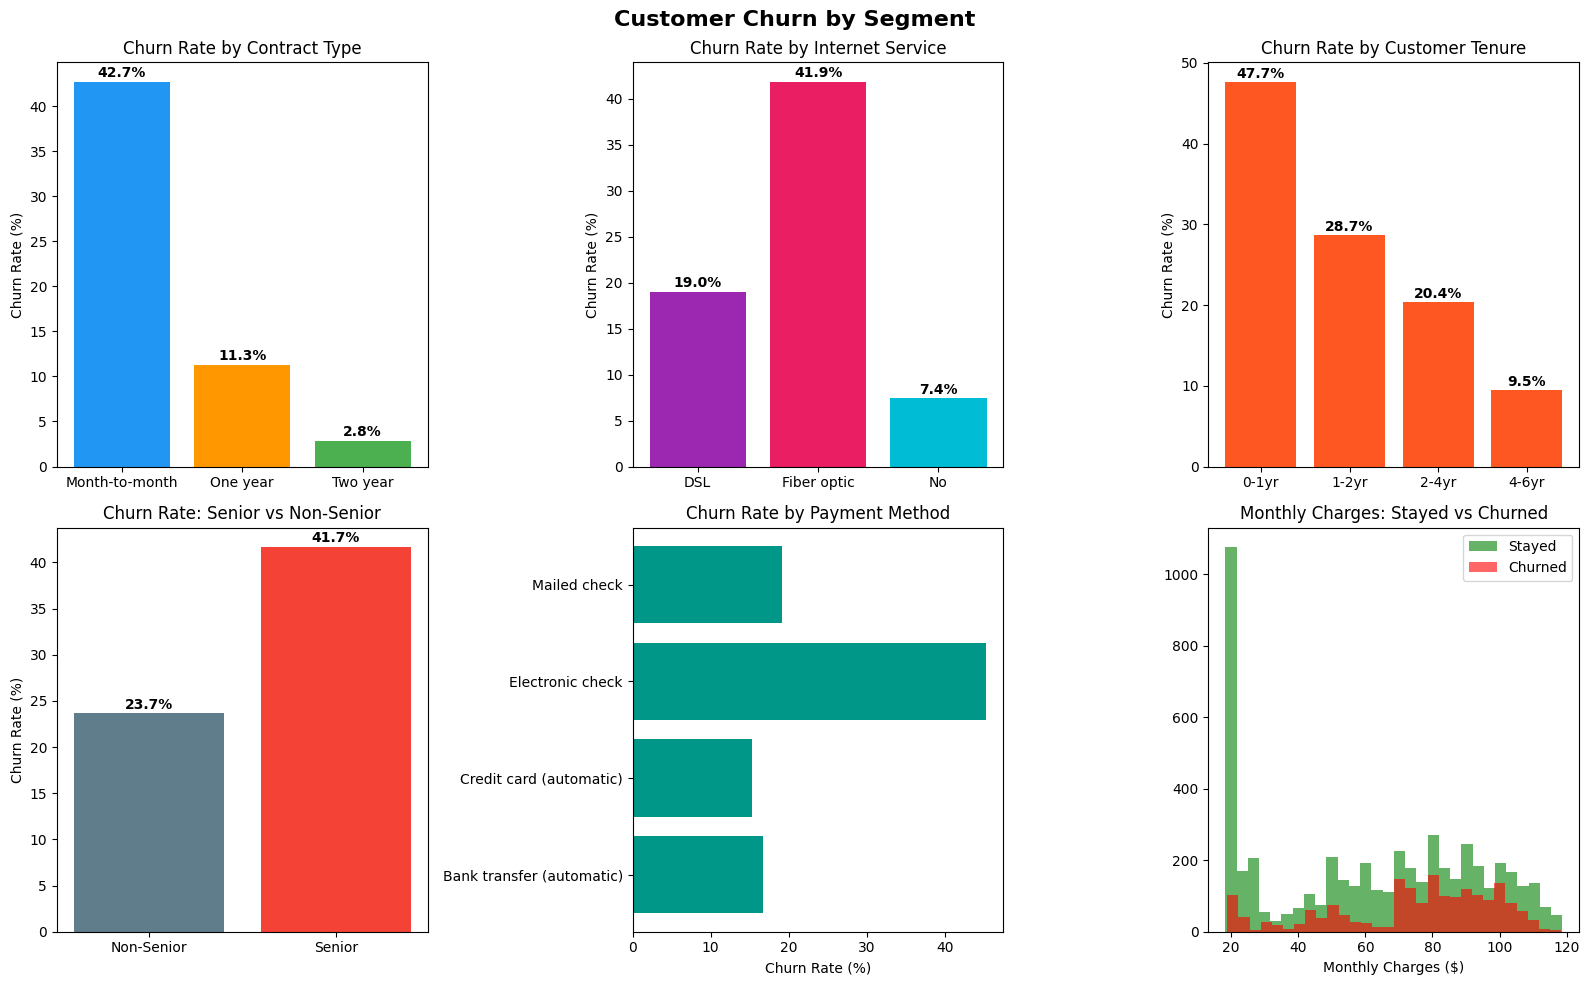

Saved: churn_by_segment.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn by Segment', fontsize=16, fontweight='bold')

contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#2196F3','#FF9800','#4CAF50'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
axes[0,1].bar(internet_churn.index, internet_churn.values, color=['#9C27B0','#E91E63','#00BCD4'])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4-6yr'])
tenure_churn = df.groupby('tenure_group')['Churn'].mean() * 100
axes[0,2].bar(tenure_churn.index.astype(str), tenure_churn.values, color='#FF5722')
axes[0,2].set_title('Churn Rate by Customer Tenure')
axes[0,2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[0,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
axes[1,0].bar(['Non-Senior','Senior'], senior_churn.values, color=['#607D8B','#F44336'])
axes[1,0].set_title('Churn Rate: Senior vs Non-Senior')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(senior_churn.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

pay_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
axes[1,1].barh(pay_churn.index, pay_churn.values, color='#009688')
axes[1,1].set_title('Churn Rate by Payment Method')
axes[1,1].set_xlabel('Churn Rate (%)')

axes[1,2].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30,
               alpha=0.6, label='Stayed', color='green')
axes[1,2].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30,
               alpha=0.6, label='Churned', color='red')
axes[1,2].set_title('Monthly Charges: Stayed vs Churned')
axes[1,2].set_xlabel('Monthly Charges ($)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('outputs/churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_by_segment.png")

In [13]:
df_ml = df.copy()
df_ml.drop('tenure_group', axis=1, inplace=True)

le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X.shape[1]}")

Training samples: 5625
Test samples: 1407
Features: 19


In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("=" * 50)
print("LOGISTIC REGRESSION")
print(f"  Accuracy : {accuracy_score(y_test, lr_preds):.3f}")
print(f"  F1 Score : {f1_score(y_test, lr_preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_proba):.3f}")

print("\nRANDOM FOREST")
print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.3f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_proba):.3f}")

LOGISTIC REGRESSION
  Accuracy : 0.796
  F1 Score : 0.597
  ROC-AUC  : 0.835

RANDOM FOREST
  Accuracy : 0.783
  F1 Score : 0.543
  ROC-AUC  : 0.811


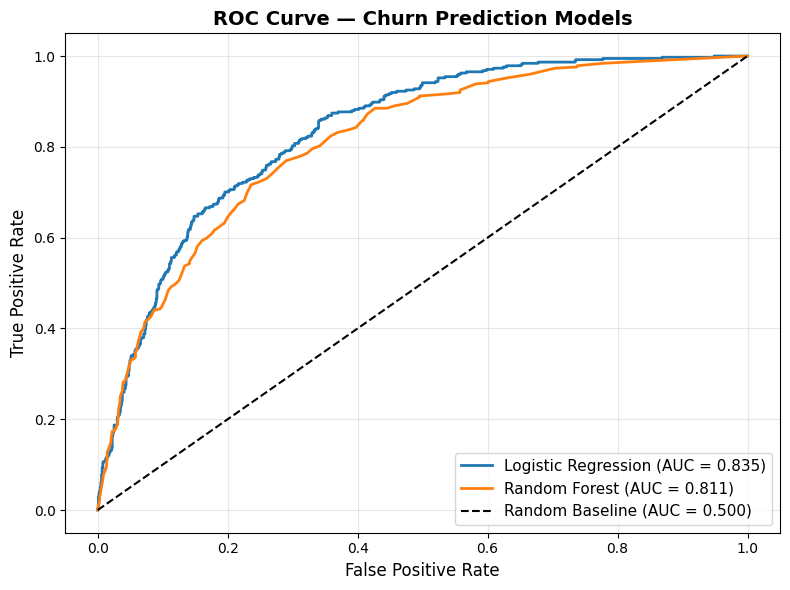

Saved: roc_curve.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, proba in [("Logistic Regression", lr_proba),
                            ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Random Baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Churn Prediction Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

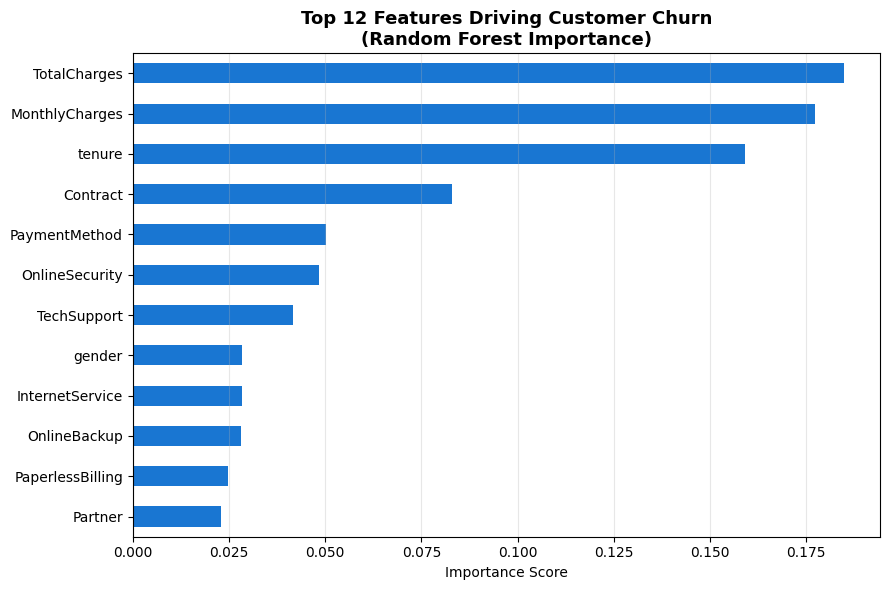

Saved: feature_importance.png


In [17]:
feat_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
feat_importance.plot(kind='barh', ax=ax, color='#1976D2')
ax.set_title('Top 12 Features Driving Customer Churn\n(Random Forest Importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

In [19]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                           ║
║           Based on Churn Analysis — Telco Dataset            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FINDING 1: Month-to-month contract customers churn at       ║
║  ~42% vs only ~3% for two-year contract customers.           ║
║  → RECOMMENDATION: Offer a 20% discount to month-to-month    ║
║    customers at the 3-month mark to convert them to          ║
║    annual contracts before churn risk peaks.                 ║
║                                                              ║
║  FINDING 2: Fiber optic internet customers churn at ~41%     ║
║  despite paying the highest monthly charges.                 ║
║  → RECOMMENDATION: Investigate service quality complaints    ║
║    in fiber optic segment. Consider a satisfaction           ║
║    survey + proactive support call at month 6.               ║
║                                                              ║
║  FINDING 3: Customers in their first 12 months churn at      ║
║  ~47% — nearly half of all new customers leave early.        ║
║  → RECOMMENDATION: Implement a structured onboarding         ║
║    program with a dedicated success check-in at day 30       ║
║    and month 3 to build early loyalty.                       ║
║                                                              ║
║  FINDING 4: Electronic check users have the highest          ║
║  churn rate among payment methods.                           ║
║  → RECOMMENDATION: Incentivize auto-pay enrollment           ║
║    (e.g. $5/month discount) to reduce friction and           ║
║    increase payment reliability correlation with retention.  ║
║                                                              ║
║  MODEL NOTE: Logistic Regression (AUC 0.835) outperformed    ║
║  Random Forest (AUC 0.811) — simpler model wins here,        ║
║  suggesting linear decision boundaries are sufficient.       ║
║  Recommend deploying LR as monthly churn risk scorer.        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                           ║
║           Based on Churn Analysis — Telco Dataset            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FINDING 1: Month-to-month contract customers churn at       ║
║  ~42% vs only ~3% for two-year contract customers.           ║
║  → RECOMMENDATION: Offer a 20% discount to month-to-month    ║
║    customers at the 3-month mark to convert them to          ║
║    annual contracts before churn risk peaks.                 ║
║                                                              ║
║  FINDING 2: Fiber optic internet customers churn at ~41%     ║
║  despite paying the highest monthly charges.                 ║
║  → RECOMMENDATION: Investigate service quality complaints    ║
║    in fiber optic segment. Consider a satisfaction           ║
║    survey + proactive 